# Análisis de la oferta de restauración en la provincia de Barcelona (OpenStreetMap 2026)

Este cuaderno realiza un análisis exploratorio del conjunto de datos de restauración en la provincia de Barcelona extraído de OpenStreetMap (`provincia_barcelona_restauracion_osm_2026.csv`).

## Objetivos del análisis
1. **Tipos de local**: Frecuencia y distribución de las distintas categorías de establecimientos (`restaurant`, `cafe`, `bar`, `fast_food`, `pub`).
2. **Tipos de cocina**: Diversidad de la oferta culinaria (`tipo_cocina`) y evaluación de la cobertura de datos.
3. **Nombres repetidos**: Identificación de cadenas, franquicias y marcas comerciales duplicadas.
4. **Concentración geoespacial provincial**: Distribución y densidad de los locales a lo largo del territorio de la provincia de Barcelona.
5. **Análisis enfocado en Barcelona ciudad**: Mapa de densidad geoespacial específico para la capital, nombres repetidos en la ciudad, excluyendo cafés y pubs, y análisis detallado del tipo de cocina en la ciudad.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración estacional y visual de matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# Carga de datos
csv_path = r"../../data/raw/restauracion_hoteles_provincia/provincia_barcelona_restauracion_osm_2026.csv"
if not os.path.exists(csv_path):
    csv_path = r"../data/raw/restauracion_hoteles_provincia/provincia_barcelona_restauracion_osm_2026.csv"

df = pd.read_csv(csv_path)
print(f"Total de registros cargados en la provincia: {len(df):,}")
df.head()

Total de registros cargados en la provincia: 16,801


,osm_id,tipo_local,nombre_comercial,tipo_cocina,calle,numero,codigo_postal,municipio,telefono,sitio_web,latitud,longitud
0,151218534,restaurant,Pans & Company,sandwich,NaN,NaN,NaN,NaN,NaN,NaN,41.724274,1.846665
1,191894875,fast_food,McDonald's,burger,NaN,NaN,NaN,NaN,NaN,NaN,41.380454,2.174184
2,191895326,fast_food,KFC,chicken,NaN,NaN,NaN,NaN,NaN,NaN,41.380308,2.174329
3,194541445,fast_food,Burger King,burger,NaN,NaN,NaN,NaN,NaN,NaN,41.374771,2.165852
4,208984374,restaurant,Central Rambla,NaN,La Rambla,26,08002,NaN,NaN,NaN,41.378272,2.176173


## Funciones auxiliares

A continuación se definen las funciones utilizadas para el cálculo de resúmenes categóricos, filtrado espacial, análisis de marcas/cadenas duplicadas y generación de visualizaciones geoespaciales. Todas las funciones cuentan con su correspondiente documentación docstring.

In [3]:
def obtener_resumen_categorica(df: pd.DataFrame, columna: str, incluir_nulos: bool = True) -> pd.DataFrame:
    """Calcula las frecuencias absolutas y relativas porcentuales de una columna categórica.

    Args:
        df (pd.DataFrame): DataFrame de datos.
        columna (str): Nombre de la columna a analizar.
        incluir_nulos (bool, optional): Indica si se incluyen valores vacíos/NaN. Por defecto True.

    Returns:
        pd.DataFrame: Tabla resumida con las columnas 'frecuencia' y 'porcentaje'.
    """
    conteo = df[columna].value_counts(dropna=not incluir_nulos)
    porcentaje = df[columna].value_counts(normalize=True, dropna=not incluir_nulos) * 100
    resumen = pd.DataFrame({'frecuencia': conteo, 'porcentaje': porcentaje.round(2)})
    return resumen

def filtrar_datos_barcelona_ciudad(df: pd.DataFrame, excluir_tipos: list = ['cafe', 'pub']) -> pd.DataFrame:
    """Filtra el conjunto de datos para delimitar la ciudad de Barcelona y excluir categorías de local específicas.

    Args:
        df (pd.DataFrame): DataFrame original con datos provinciales.
        excluir_tipos (list, optional): Lista de tipos de local a excluir. Por defecto ['cafe', 'pub'].

    Returns:
        pd.DataFrame: Subconjunto filtrado para Barcelona ciudad excluyendo los tipos indicados.
    """
    # Delimitación geoespacial del término municipal de la ciudad de Barcelona
    cond_lat = (df['latitud'] >= 41.32) & (df['latitud'] <= 41.47)
    cond_lon = (df['longitud'] >= 2.05) & (df['longitud'] <= 2.24)
    
    df_bcn = df[cond_lat & cond_lon].copy()
    if excluir_tipos:
        df_bcn = df_bcn[~df_bcn['tipo_local'].isin(excluir_tipos)].copy()
        
    return df_bcn

def analizar_nombres_duplicados(df: pd.DataFrame, columna_nombre: str = 'nombre_comercial') -> dict:
    """Identifica los nombres comerciales repetidos en el conjunto de datos.

    Args:
        df (pd.DataFrame): DataFrame con la información de los establecimientos.
        columna_nombre (str, optional): Nombre de la columna de nombres comerciales. Por defecto 'nombre_comercial'.

    Returns:
        dict: Diccionario con estadísticas globales de duplicación y el DataFrame de marcas más repetidas.
    """
    df_validos = df[df[columna_nombre].notna()]
    conteo_nombres = df_validos[columna_nombre].value_counts()
    
    nombres_unicos_total = len(conteo_nombres)
    nombres_repetidos = conteo_nombres[conteo_nombres > 1]
    nombres_unicos_exclusivos = conteo_nombres[conteo_nombres == 1]
    
    locales_en_cadenas = nombres_repetidos.sum()
    locales_independientes = nombres_unicos_exclusivos.sum()
    
    top_cadenas = pd.DataFrame({
        'nombre_comercial': nombres_repetidos.index,
        'num_locales': nombres_repetidos.values
    })
    
    return {
        'total_locales_con_nombre': len(df_validos),
        'total_nombres_distintos': nombres_unicos_total,
        'num_nombres_repetidos': len(nombres_repetidos),
        'num_locales_en_cadenas': locales_en_cadenas,
        'num_locales_independientes': locales_independientes,
        'top_cadenas': top_cadenas
    }

def generar_grafico_barras(df_datos: pd.DataFrame, col_x: str, col_y: str, titulo: str, xlabel: str, ylabel: str, color: str = '#1f77b4', es_horizontal: bool = True) -> None:
    """Genera y muestra un gráfico de barras estilizado.

    Args:
        df_datos (pd.DataFrame): DataFrame con los datos a graficar.
        col_x (str): Nombre de la columna para el eje X (o Y si es horizontal).
        col_y (str): Nombre de la columna para el eje Y (o X si es horizontal).
        titulo (str): Título del gráfico.
        xlabel (str): Etiqueta del eje X.
        ylabel (str): Etiqueta del eje Y.
        color (str, optional): Color primario de las barras. Por defecto '#1f77b4'.
        es_horizontal (bool, optional): Si True se grafica en horizontal. Por defecto True.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    if es_horizontal:
        barras = ax.barh(df_datos[col_x], df_datos[col_y], color=color, edgecolor='none', alpha=0.85)
        ax.invert_yaxis()
        for barra in barras:
            ancho = barra.get_width()
            ax.annotate(f'{ancho:,.0f}',
                        xy=(ancho, barra.get_y() + barra.get_height() / 2),
                        xytext=(5, 0), textcoords="offset points",
                        ha='left', va='center', fontsize=9, fontweight='bold', color='#333333')
    else:
        barras = ax.bar(df_datos[col_x], df_datos[col_y], color=color, edgecolor='none', alpha=0.85)
        for barra in barras:
            alto = barra.get_height()
            ax.annotate(f'{alto:,.0f}',
                        xy=(barra.get_x() + barra.get_width() / 2, alto),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')
    
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=10, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=10)
    plt.tight_layout()
    plt.show()

def generar_mapa_densidad_geoespacial(df_geo: pd.DataFrame, lat_col: str = 'latitud', lon_col: str = 'longitud', titulo: str = 'Mapa de densidad de restauración') -> None:
    """Genera gráficos geoespaciales de concentración mediante mapas de densidad hexagonal y distribución por categoría.

    Args:
        df_geo (pd.DataFrame): DataFrame con coordenadas geoespaciales válidas.
        lat_col (str, optional): Columna de latitud. Por defecto 'latitud'.
        lon_col (str, optional): Columna de longitud. Por defecto 'longitud'.
        titulo (str, optional): Título del gráfico principal. Por defecto 'Mapa de densidad de restauración'.
    """
    df_valido = df_geo[df_geo[lat_col].notna() & df_geo[lon_col].notna()]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # 1. Hexbin plot (densidad)
    hb = ax1.hexbin(df_valido[lon_col], df_valido[lat_col], gridsize=40, cmap='YlOrRd', mincnt=1, bins='log')
    cb = fig.colorbar(hb, ax=ax1, orientation='vertical', shrink=0.8)
    cb.set_label('Número de locales (escala logarítmica)', fontsize=9)
    ax1.set_title(f'{titulo} - Densidad (Hexbin)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Longitud', fontsize=10)
    ax1.set_ylabel('Latitud', fontsize=10)
    
    # 2. Scatter plot por tipo de local
    tipos = df_valido['tipo_local'].unique()
    cmap_fun = plt.get_cmap('tab10')
    
    for i, tipo in enumerate(tipos):
        sub = df_valido[df_valido['tipo_local'] == tipo]
        ax2.scatter(sub[lon_col], sub[lat_col], label=tipo, color=cmap_fun(i % 10), alpha=0.4, s=8)
        
    ax2.set_title('Distribución geoespacial por tipo de local', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Longitud', fontsize=10)
    ax2.set_ylabel('Latitud', fontsize=10)
    ax2.legend(title='Tipo de local', markerscale=3, loc='upper left')
    
    plt.tight_layout()
    plt.show()

## 1. Tipos de local y cuántos

Analizamos las categorías principales de la oferta de restauración registradas en OpenStreetMap en la provincia de Barcelona.

,frecuencia,porcentaje
tipo_local,,
restaurant,8696,51.76
cafe,2865,17.05
bar,2496,14.86
fast_food,1398,8.32
pub,1346,8.01


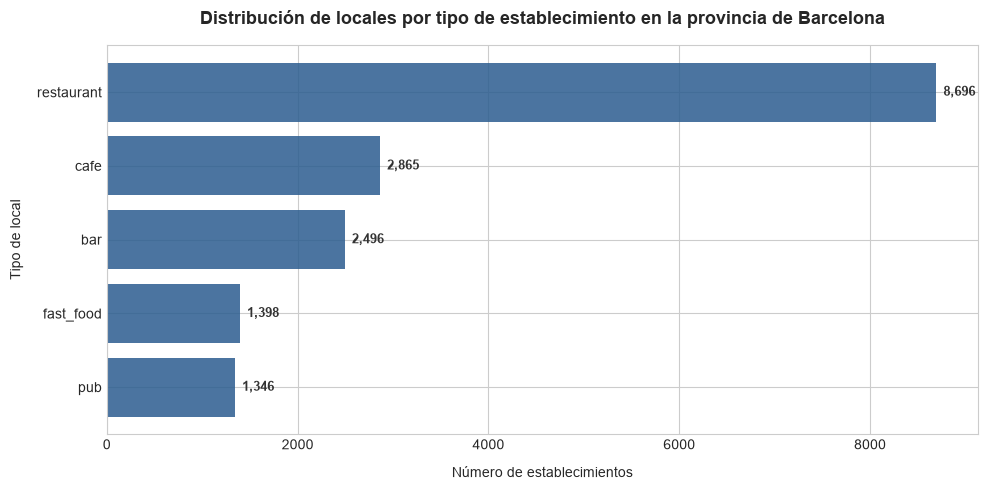

In [4]:
resumen_tipos = obtener_resumen_categorica(df, 'tipo_local', incluir_nulos=False)
display(resumen_tipos)

# Gráfico de barras de tipos de local
df_grafico_tipos = resumen_tipos.reset_index()
df_grafico_tipos.columns = ['tipo_local', 'frecuencia', 'porcentaje']

generar_grafico_barras(
    df_grafico_tipos,
    col_x='tipo_local',
    col_y='frecuencia',
    titulo='Distribución de locales por tipo de establecimiento en la provincia de Barcelona',
    xlabel='Número de establecimientos',
    ylabel='Tipo de local',
    color='#2b5c8f',
    es_horizontal=True
)

## 2. Tipos de cocina (provincial)

Analizamos la distribución de tipos de cocina (`tipo_cocina`) y la cobertura de datos en esta columna a nivel provincial.

Total establecimientos: 16,801
Con tipo de cocina especificado: 5,527 (32.90%)
Sin tipo de cocina especificado (NaN): 11,274 (67.10%)


,frecuencia,porcentaje
tipo_cocina,,
regional,592,10.71
pizza,400,7.24
burger,331,5.99
spanish,304,5.50
japanese,237,4.29
coffee_shop,233,4.22
tapas,219,3.96
italian,175,3.17
kebab,167,3.02


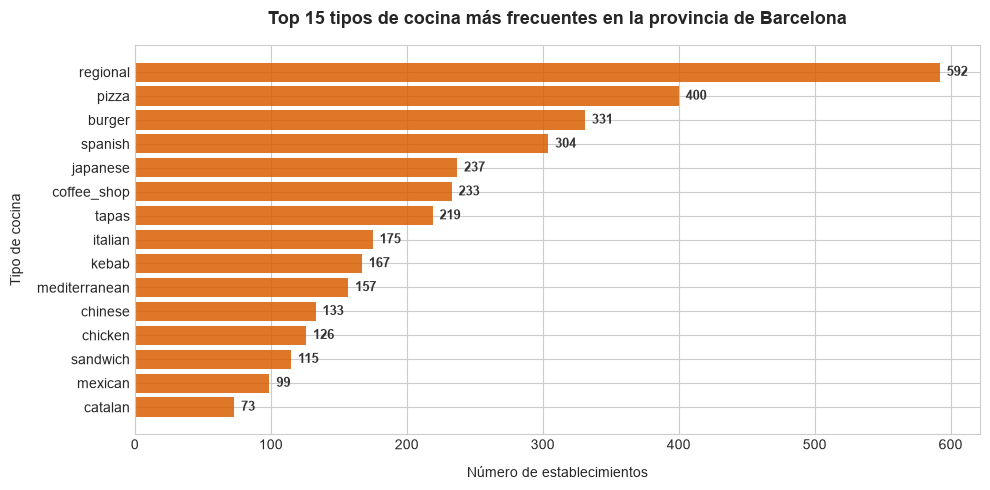

In [5]:
total_registros = len(df)
nulos_cocina = df['tipo_cocina'].isna().sum()
informados_cocina = total_registros - nulos_cocina

print(f"Total establecimientos: {total_registros:,}")
print(f"Con tipo de cocina especificado: {informados_cocina:,} ({informados_cocina/total_registros*100:.2f}%)")
print(f"Sin tipo de cocina especificado (NaN): {nulos_cocina:,} ({nulos_cocina/total_registros*100:.2f}%)")

# Top 15 tipos de cocina entre los registros especificados
resumen_cocina = obtener_resumen_categorica(df, 'tipo_cocina', incluir_nulos=False).head(15)
display(resumen_cocina)

df_grafico_cocina = resumen_cocina.reset_index()
df_grafico_cocina.columns = ['tipo_cocina', 'frecuencia', 'porcentaje']

generar_grafico_barras(
    df_grafico_cocina,
    col_x='tipo_cocina',
    col_y='frecuencia',
    titulo='Top 15 tipos de cocina más frecuentes en la provincia de Barcelona',
    xlabel='Número de establecimientos',
    ylabel='Tipo de cocina',
    color='#d95f02',
    es_horizontal=True
)

## 3. Nombres repetidos y cadenas comerciales

Evaluamos los nombres comerciales (`nombre_comercial`) para detectar cuántos locales corresponden a marcas/cadenas repetidas frente a establecimientos con nombre único e independiente.

Total locales con nombre comercial: 15,570
Total nombres distintos/únicos: 13,449
Nombres que se repiten (count > 1): 933
Locales asociados a nombres repetidos (cadenas/franquicias): 3,054 (19.61%)
Locales independientes (nombre único): 12,516 (80.39%)
--- TOP 20 MARCAS / NOMBRES MÁS REPETIDOS ---


,nombre_comercial,num_locales
0,365,84
1,McDonald's,77
2,Burger King,76
3,Vivari,55
4,KFC,38
5,La Tagliatella,33
6,Viena,31
7,Telepizza,29
8,Starbucks,28
9,Domino's,25


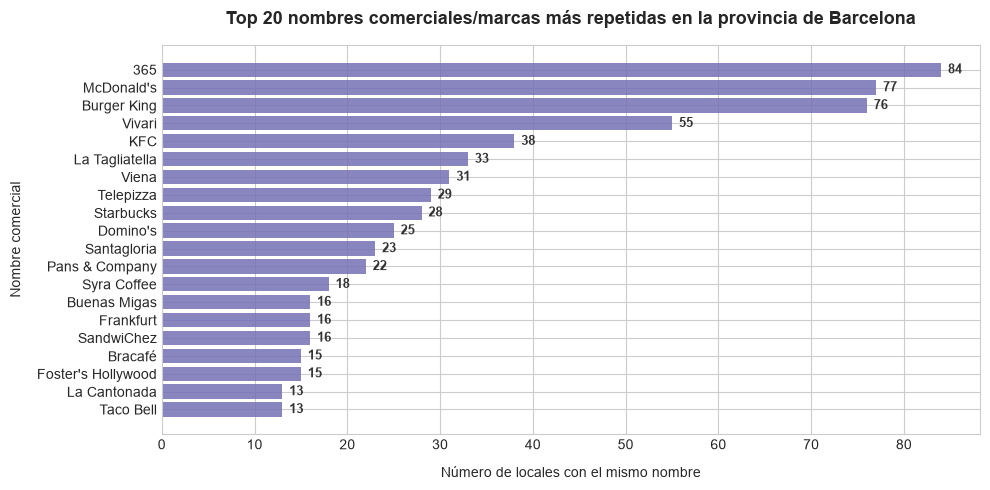

In [6]:
analisis_nombres = analizar_nombres_duplicados(df, 'nombre_comercial')

print(f"Total locales con nombre comercial: {analisis_nombres['total_locales_con_nombre']:,}")
print(f"Total nombres distintos/únicos: {analisis_nombres['total_nombres_distintos']:,}")
print(f"Nombres que se repiten (count > 1): {analisis_nombres['num_nombres_repetidos']:,}")
print(f"Locales asociados a nombres repetidos (cadenas/franquicias): {analisis_nombres['num_locales_en_cadenas']:,} ({analisis_nombres['num_locales_en_cadenas']/analisis_nombres['total_locales_con_nombre']*100:.2f}%)")
print(f"Locales independientes (nombre único): {analisis_nombres['num_locales_independientes']:,} ({analisis_nombres['num_locales_independientes']/analisis_nombres['total_locales_con_nombre']*100:.2f}%)")

print("--- TOP 20 MARCAS / NOMBRES MÁS REPETIDOS ---")
top_20_cadenas = analisis_nombres['top_cadenas'].head(20)
display(top_20_cadenas)

generar_grafico_barras(
    top_20_cadenas,
    col_x='nombre_comercial',
    col_y='num_locales',
    titulo='Top 20 nombres comerciales/marcas más repetidas en la provincia de Barcelona',
    xlabel='Número de locales con el mismo nombre',
    ylabel='Nombre comercial',
    color='#7570b3',
    es_horizontal=True
)

## 4. Concentración geoespacial provincial

Analizamos la densidad geográfica de la oferta de restauración a través de las coordenadas de latitud y longitud a nivel provincial.

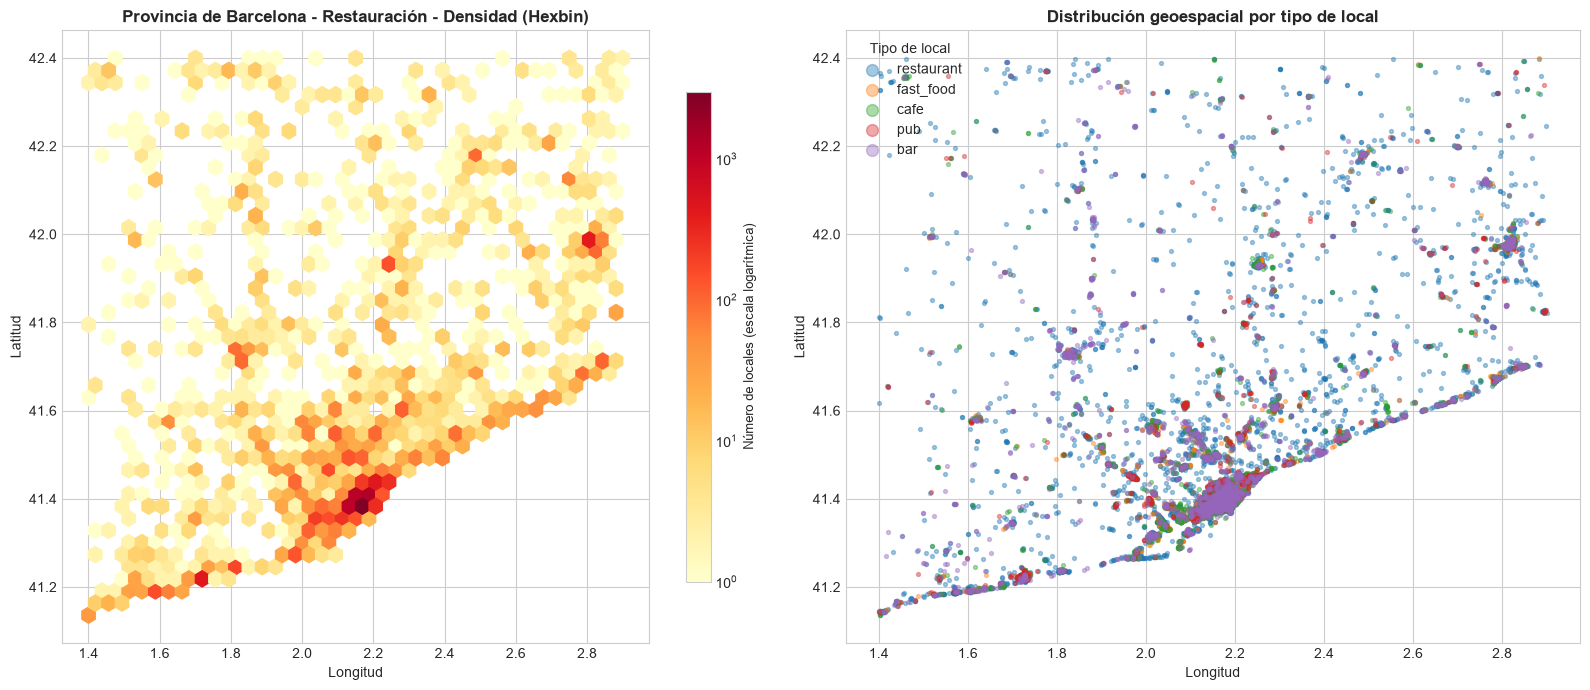

--- TOP 15 MUNICIPIOS CON MÁS REGISTROS INFORMADOS EN OSM ---


,frecuencia,porcentaje
municipio,,
Barcelona,1442,39.94
Sant Boi de Llobregat,224,6.20
Calafell,163,4.52
Badalona,97,2.69
Girona,89,2.47
Santa Coloma de Gramenet,84,2.33
Sant Andreu de la Barca,77,2.13
Sant Cugat del Vallès,74,2.05
l'Hospitalet de Llobregat,54,1.50


In [7]:
# Generar mapas de concentración geoespacial provincial
generar_mapa_densidad_geoespacial(df, lat_col='latitud', lon_col='longitud', titulo='Provincia de Barcelona - Restauración')

# Concentración por municipio (donde el campo municipio está informado)
resumen_municipio = obtener_resumen_categorica(df, 'municipio', incluir_nulos=False).head(15)
print("--- TOP 15 MUNICIPIOS CON MÁS REGISTROS INFORMADOS EN OSM ---")
display(resumen_municipio)

## 5. Análisis enfocado en Barcelona ciudad

En esta sección aplicamos un filtro geoespacial exclusivo para el término municipal de la **ciudad de Barcelona** y analizamos la concentración geoespacial, los nombres repetidos y los tipos de cocina (excluyendo cafés y pubs).

Total locales en la ciudad de Barcelona (sin cafés ni pubs): 6,291
--- DISTRIBUCIÓN POR TIPO DE LOCAL EN BARCELONA CIUDAD ---


,frecuencia,porcentaje
tipo_local,,
restaurant,4296,68.29
bar,1209,19.22
fast_food,786,12.49


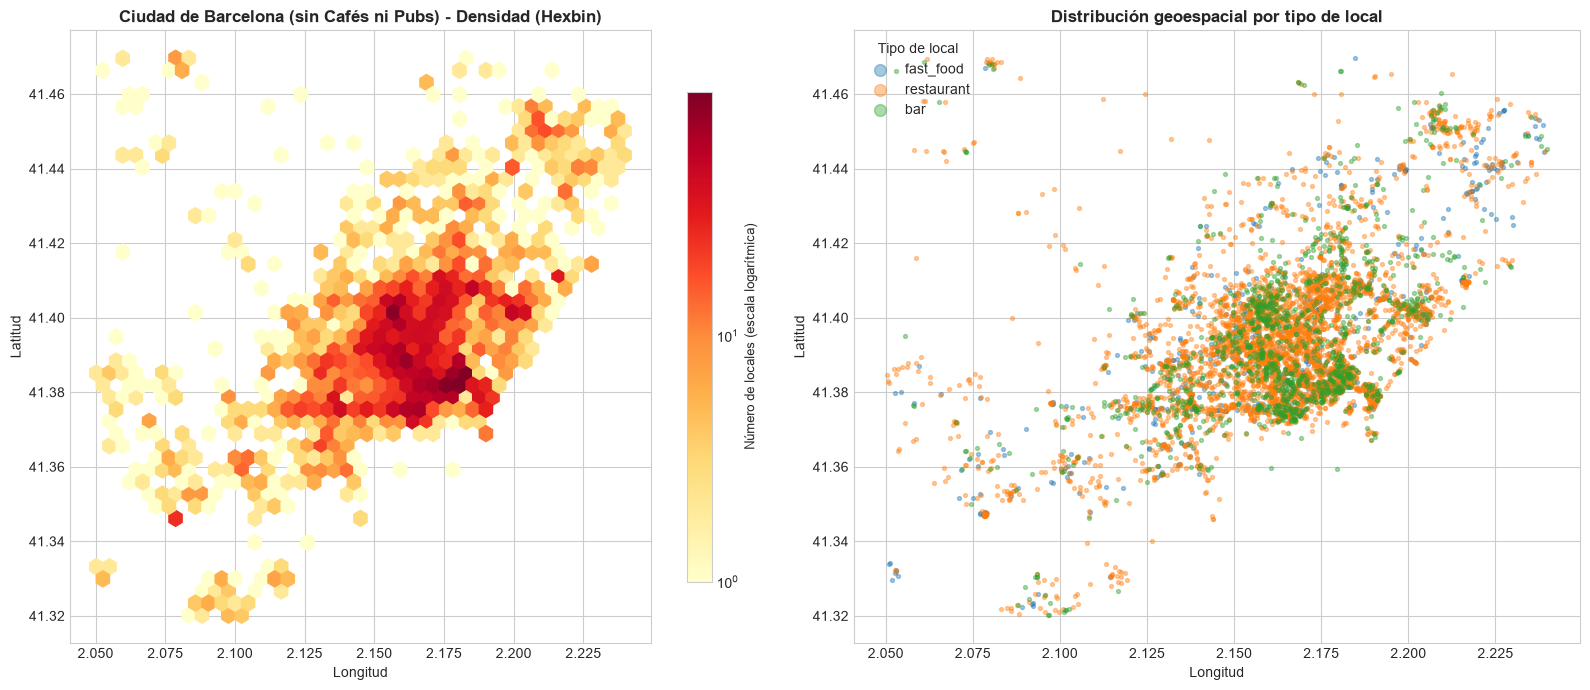

In [8]:
# Filtrado de datos para la ciudad de Barcelona (sin cafés ni pubs)
df_bcn_restauracion = filtrar_datos_barcelona_ciudad(df, excluir_tipos=['cafe', 'pub'])

print(f"Total locales en la ciudad de Barcelona (sin cafés ni pubs): {len(df_bcn_restauracion):,}")
print("--- DISTRIBUCIÓN POR TIPO DE LOCAL EN BARCELONA CIUDAD ---")
resumen_tipos_bcn = obtener_resumen_categorica(df_bcn_restauracion, 'tipo_local', incluir_nulos=False)
display(resumen_tipos_bcn)

# Mapa de densidad geoespacial exclusivo de Barcelona ciudad
generar_mapa_densidad_geoespacial(
    df_bcn_restauracion,
    lat_col='latitud',
    lon_col='longitud',
    titulo='Ciudad de Barcelona (sin Cafés ni Pubs)'
)

In [9]:
# Análisis de nombres repetidos exclusivamente en Barcelona ciudad
df_bcn_todos = filtrar_datos_barcelona_ciudad(df, excluir_tipos=[])
analisis_nombres_bcn_total = analizar_nombres_duplicados(df_bcn_todos, 'nombre_comercial')
analisis_nombres_bcn_filtrado = analizar_nombres_duplicados(df_bcn_restauracion, 'nombre_comercial')

print("--- NOMBRES REPETIDOS EN BARCELONA CIUDAD (TODOS LOS LOCALES) ---")
print(f"Total locales con nombre: {analisis_nombres_bcn_total['total_locales_con_nombre']:,}")
print(f"Nombres distintos: {analisis_nombres_bcn_total['total_nombres_distintos']:,}")
print(f"Nombres repetidos (count > 1): {analisis_nombres_bcn_total['num_nombres_repetidos']:,}")
print(f"Locales en cadenas/marcas repetidas: {analisis_nombres_bcn_total['num_locales_en_cadenas']:,} ({analisis_nombres_bcn_total['num_locales_en_cadenas']/analisis_nombres_bcn_total['total_locales_con_nombre']*100:.2f}%)")

print("\n--- NOMBRES REPETIDOS EN BARCELONA CIUDAD (SIN CAFÉS NI PUBS) ---")
print(f"Total locales con nombre: {analisis_nombres_bcn_filtrado['total_locales_con_nombre']:,}")
print(f"Nombres distintos: {analisis_nombres_bcn_filtrado['total_nombres_distintos']:,}")
print(f"Nombres repetidos (count > 1): {analisis_nombres_bcn_filtrado['num_nombres_repetidos']:,}")
print(f"Locales en cadenas/marcas repetidas: {analisis_nombres_bcn_filtrado['num_locales_en_cadenas']:,} ({analisis_nombres_bcn_filtrado['num_locales_en_cadenas']/analisis_nombres_bcn_filtrado['total_locales_con_nombre']*100:.2f}%)")

print("\n--- TOP 15 MARCAS REPETIDAS EN BARCELONA CIUDAD (SIN CAFÉS NI PUBS) ---")
display(analisis_nombres_bcn_filtrado['top_cadenas'].head(15))

--- NOMBRES REPETIDOS EN BARCELONA CIUDAD (TODOS LOS LOCALES) ---
Total locales con nombre: 8,248
Nombres distintos: 7,205
Nombres repetidos (count > 1): 440
Locales en cadenas/marcas repetidas: 1,483 (17.98%)

--- NOMBRES REPETIDOS EN BARCELONA CIUDAD (SIN CAFÉS NI PUBS) ---
Total locales con nombre: 6,032
Nombres distintos: 5,421
Nombres repetidos (count > 1): 299
Locales en cadenas/marcas repetidas: 910 (15.09%)

--- TOP 15 MARCAS REPETIDAS EN BARCELONA CIUDAD (SIN CAFÉS NI PUBS) ---


,nombre_comercial,num_locales
0,McDonald's,33
1,Burger King,28
2,KFC,20
3,La Tagliatella,17
4,Pans & Company,16
5,Telepizza,12
6,Domino's,11
7,Honest Greens,10
8,SandwiChez,10
9,Taco Bell,10


Total locales analizados en Barcelona ciudad: 6,291
Con tipo de cocina especificado: 2,708 (43.05%)
Sin tipo de cocina especificado (NaN): 3,583 (56.95%)
--- TOP 20 TIPOS DE COCINA EN BARCELONA CIUDAD (SIN CAFÉS NI PUBS) ---


,frecuencia,porcentaje
tipo_cocina,,
pizza,180,6.65
spanish,176,6.50
burger,170,6.28
japanese,164,6.06
regional,144,5.32
tapas,142,5.24
italian,110,4.06
chinese,84,3.10
mexican,75,2.77


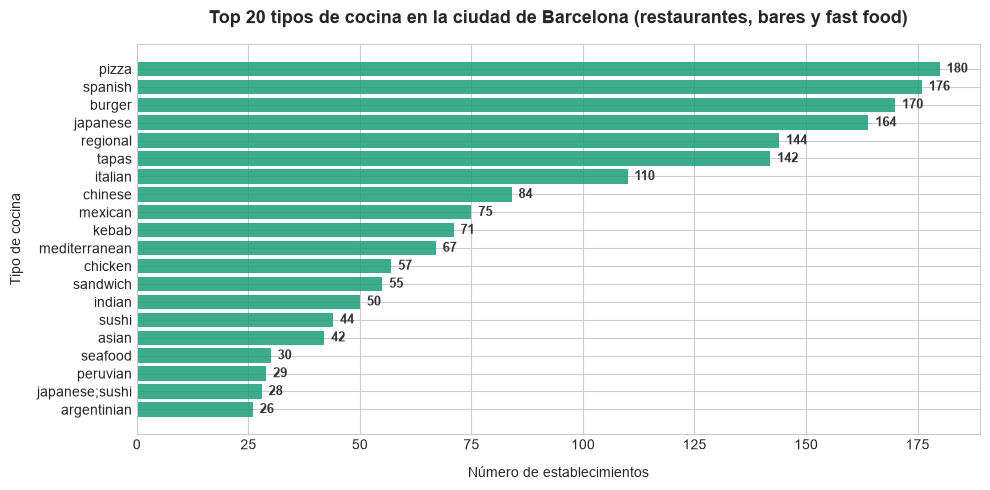

In [10]:
# Análisis detallado del tipo de cocina en la ciudad de Barcelona (sin cafés ni pubs)
total_bcn = len(df_bcn_restauracion)
nulos_cocina_bcn = df_bcn_restauracion['tipo_cocina'].isna().sum()
informados_cocina_bcn = total_bcn - nulos_cocina_bcn

print(f"Total locales analizados en Barcelona ciudad: {total_bcn:,}")
print(f"Con tipo de cocina especificado: {informados_cocina_bcn:,} ({informados_cocina_bcn/total_bcn*100:.2f}%)")
print(f"Sin tipo de cocina especificado (NaN): {nulos_cocina_bcn:,} ({nulos_cocina_bcn/total_bcn*100:.2f}%)")

# Top 20 tipos de cocina en Barcelona ciudad
resumen_cocina_bcn = obtener_resumen_categorica(df_bcn_restauracion, 'tipo_cocina', incluir_nulos=False).head(20)
print("--- TOP 20 TIPOS DE COCINA EN BARCELONA CIUDAD (SIN CAFÉS NI PUBS) ---")
display(resumen_cocina_bcn)

df_grafico_cocina_bcn = resumen_cocina_bcn.reset_index()
df_grafico_cocina_bcn.columns = ['tipo_cocina', 'frecuencia', 'porcentaje']

generar_grafico_barras(
    df_grafico_cocina_bcn,
    col_x='tipo_cocina',
    col_y='frecuencia',
    titulo='Top 20 tipos de cocina en la ciudad de Barcelona (restaurantes, bares y fast food)',
    xlabel='Número de establecimientos',
    ylabel='Tipo de cocina',
    color='#1b9e77',
    es_horizontal=True
)

## 6. Resumen de hallazgos clave

### Respuestas a las preguntas planteadas
- **Tipos de local a nivel provincial**: Existen 16.801 locales de restauración en total (`restaurant`: 51,76%, `cafe`: 17,05%, `bar`: 14,86%, `fast_food`: 8,32%, `pub`: 8,01%).
- **Análisis específico para Barcelona ciudad**:
  - **Nombres repetidos en Barcelona ciudad (todos los locales)**: Hay **440 nombres repetidos** (que suman 1.483 locales en cadenas/marcas, 17,98% del total). Las cadenas líderes son 365 (74), Vivari (48), McDonald's (33), Burger King (28) y Starbucks (25).
  - **Nombres repetidos en Barcelona ciudad (sin cafés ni pubs)**: Hay **299 nombres repetidos** (910 locales, 15,09%). Cadenas líderes: McDonald's (33), Burger King (28), KFC (20), La Tagliatella (17), Pans & Company (16) y Telepizza (12).
  - **Distribución de categorías (sin cafés ni pubs)**: 6.291 establecimientos (`restaurant`: 4.296, `bar`: 1.209, `fast_food`: 786).
  - **Tipos de cocina (sin cafés ni pubs)**: El 43,05% (2.708 locales) especifica el tipo de cocina. Top 5: Pizza (180), Spanish (176), Burger (170), Japanese (164) y Regional (144).